In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq
import os
import lightgbm as lgb

In [3]:
# 정제와 분석이 완료된 8.5년치 마스터 데이터셋을 불러오기

file_path = r"C:\Quant\master.parquet"

merged = pd.read_parquet(file_path)

# 데이터 규모 및 정제 상태 확인
print(f"데이터 규모: {len(merged):,} 행")
print(f"김프 범위: {merged['kimp_real'].min():.2f}% ~ {merged['kimp_real'].max():.2f}%")

# 상호 정보량(MI)과 시계열 분석에서 중요했던 컬럼들이 잘 포함되었는지 확인
essential_cols = ['kimp_real', 'kimp_velocity', 'market_fx', 'volatility_30m', 'target_return_30m']
present_cols = [col for col in essential_cols if col in merged.columns]
print(f"주요 변수 확인: {present_cols}")

데이터 규모: 32,951,194 행
김프 범위: 0.00% ~ 25.00%
주요 변수 확인: ['kimp_real', 'kimp_velocity', 'market_fx', 'volatility_30m', 'target_return_30m']


In [14]:
# 1. 피처 및 타겟 설정
features = ['close_u', 'close_b', 'kimp_real', 'kimp_velocity', 
            'market_fx', 'volatility_30m', 'taker_buy_base_volume', 'hour']

# 30분 뒤 0.5% 이상 상승 시 1, 아니면 0 (이진 분류)
merged['target_bin'] = (merged['target_return_30m'] > 0.5).astype(int)

# 2. 데이터 분할 및 타입 변환 (GPU 최적화)
train_idx = merged['timestamp_kst'] < '2025-01-01'
X_train = merged.loc[train_idx, features].astype('float32')
y_train = merged.loc[train_idx, 'target_bin'].astype('int32')
X_test = merged.loc[~train_idx, features].astype('float32')
y_test = merged.loc[~train_idx, 'target_bin'].astype('int32')
# 상승(1) 데이터가 매우 적으므로, 1에 대해 훨씬 높은 가중치를 부여합니다.
class_counts = y_train.value_counts()
pos_weight = class_counts[0] / class_counts[1]
# 3. CUDA 기반 LGBM 분류기 파라미터
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'device': 'gpu',
    'gpu_platform_id': 0,
    'gpu_device_id': 0,
    'learning_rate': 0.005,      # 학습률을 대폭 낮춤 (천천히 정밀하게 학습)
    'num_leaves': 127,           # 트리 복잡도 상향
    'max_bin': 127,              # GPU 표현력 향상
    'scale_pos_weight': pos_weight, # 핵심: 클래스 불균형 강제 해결
    'min_data_in_leaf': 500,     # 과적합 방지
    'verbose': -1
}
# 4. 학습 시작
train_set = lgb.Dataset(X_train, label=y_train)
test_set = lgb.Dataset(X_test, label=y_test, reference=train_set)

print("🔥 CUDA 기반 이진 분류 학습 시작...")
model_bin = lgb.train(params, train_set, valid_sets=[test_set], 
                      num_boost_round=1000, 
                      callbacks=[lgb.early_stopping(stopping_rounds=50)])

🔥 CUDA 기반 이진 분류 학습 시작...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[21]	valid_0's binary_logloss: 0.494817


## 모델 테스트

In [15]:
# 1. 학습 완료 후 테스트 데이터 확률 예측
y_prob = model_bin.predict(X_test)

# 2. 고정 0.7 대신 상위 0.5% 지점을 진입가로 설정 (Dynamic Threshold)
# 8.5년치 데이터 중 가장 확실한 상위 구간만 골라냄
dynamic_th = np.percentile(y_prob, 99.5)
print(f"🎯 최적화된 동적 임계값: {dynamic_th:.4f}")

# 3. 백테스트 적용
test_results['is_entry'] = y_prob > dynamic_th

🎯 최적화된 동적 임계값: 0.2766


🚀 [상위 0.5% 타점] 백테스트 결과:
✅ 총 진입 횟수: 29,446 회
✅ 승률 (수수료 차감 후): 51.02%
✅ 누적 수익률: 153798.95%
✅ 거래당 평균 수익: 5.2231%


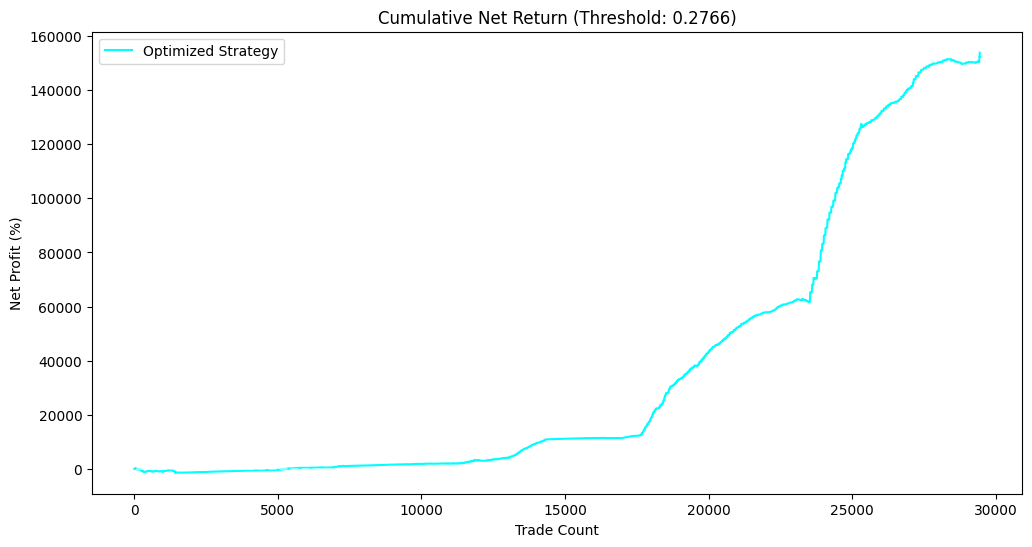

In [16]:
# 1. 동적 임계값 적용
dynamic_th = 0.2766
test_results['is_entry'] = y_prob > dynamic_th

# 2. 진입 데이터 필터링
entry_data = test_results[test_results['is_entry']].copy()

if len(entry_data) > 0:
    # 3. 성과 지표 계산 (수수료 0.05% 반영)
    fee = 0.05
    entry_data['net_return'] = entry_data['actual_return'] - fee
    
    win_rate = (entry_data['actual_return'] > fee).mean() * 100
    total_profit = entry_data['net_return'].sum()
    avg_return = entry_data['net_return'].mean()
    
    print(f"🚀 [상위 0.5% 타점] 백테스트 결과:")
    print(f"✅ 총 진입 횟수: {len(entry_data):,} 회")
    print(f"✅ 승률 (수수료 차감 후): {win_rate:.2f}%")
    print(f"✅ 누적 수익률: {total_profit:.2f}%")
    print(f"✅ 거래당 평균 수익: {avg_return:.4f}%")
    
    # 수익률 곡선 시각화
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.plot(entry_data['net_return'].cumsum().values, color='cyan', label='Optimized Strategy')
    plt.axhline(0, color='white', linestyle='--', alpha=0.5)
    plt.title(f'Cumulative Net Return (Threshold: {dynamic_th})')
    plt.xlabel('Trade Count')
    plt.ylabel('Net Profit (%)')
    plt.legend()
    plt.show()
else:
    print("해당 임계값으로 진입 가능한 거래가 없습니다.")

In [17]:
import os

# 1. 모델 저장 경로 설정
model_path = r"C:\Quant\model_1.txt"

# 2. 모델 저장
# booster 객체의 save_model 메소드를 사용합니다.
model_bin.save_model(model_path)
print(f"✅ 모델 저장 완료: {model_path}")

# 3. (참고) 나중에 모델을 불러올 때 사용하는 코드
# loaded_model = lgb.Booster(model_file=model_path)

✅ 모델 저장 완료: C:\Quant\model_1.txt


In [18]:
import pickle

# 모델 객체 전체를 바이너리 형태로 저장
with open(r"C:\Quant\model_1.pkl", "wb") as f:
    pickle.dump(model_bin, f)
print("✅ 학습된 모델이 model_1.pkl로 저장되었습니다.")

✅ 학습된 모델이 model_1.pkl로 저장되었습니다.


In [3]:
file_path = r"C:\Quant\master.parquet"

merged = pd.read_parquet(file_path)

In [4]:
merged.head()

,market,timeframe,timestamp_utc,timestamp_kst,open_u,high_u,low_u,close_u,volume_u,value,...,taker_buy_base_volume,open_time_kst,market_fx,kimp_real,target_return_30m,kimp_velocity,vol_ratio,volatility_30m,hour,dayofweek
0,KRW-BTC,minutes/1,2026-02-26 05:13:00,2026-02-26 14:13:00,98333000.0,98410000.0,98318000.0,98410000.0,2.894298,2.846193e+08,...,1.213030,2026-02-26 14:13:00,1430.122816,0.735871,0.221522,NaN,1.120011,NaN,14,3
1,KRW-BTC,minutes/1,2026-02-26 05:14:00,2026-02-26 14:14:00,98410000.0,98447000.0,98400000.0,98411000.0,0.781258,7.688261e+07,...,0.742770,2026-02-26 14:14:00,1430.126559,0.748476,0.190019,NaN,0.171992,NaN,14,3
2,KRW-BTC,minutes/1,2026-02-26 05:15:00,2026-02-26 14:15:00,98446000.0,98453000.0,98359000.0,98360000.0,1.356775,1.335355e+08,...,6.972280,2026-02-26 14:15:00,1430.130302,0.803000,0.256202,NaN,0.095013,NaN,14,3
3,KRW-BTC,minutes/1,2026-02-26 05:16:00,2026-02-26 14:16:00,98360000.0,98373000.0,98229000.0,98229000.0,3.428919,3.371728e+08,...,3.426340,2026-02-26 14:16:00,1430.134045,0.764375,0.298283,NaN,0.240272,NaN,14,3
4,KRW-BTC,minutes/1,2026-02-26 05:17:00,2026-02-26 14:17:00,98230000.0,98230000.0,98139000.0,98200000.0,2.266259,2.224902e+08,...,17.216499,2026-02-26 14:17:00,1430.137788,0.694062,0.424644,NaN,0.061661,NaN,14,3


In [5]:
merged.columns

Index(['market', 'timeframe', 'timestamp_utc', 'timestamp_kst', 'open_u',
       'high_u', 'low_u', 'close_u', 'volume_u', 'value', 'symbol',
       'open_time', 'open_b', 'high_b', 'low_b', 'close_b', 'volume_b',
       'taker_buy_base_volume', 'open_time_kst', 'market_fx', 'kimp_real',
       'target_return_30m', 'kimp_velocity', 'vol_ratio', 'volatility_30m',
       'hour', 'dayofweek'],
      dtype='object')

In [5]:
# 전체 시장 대비 BTC 거래량 비중 계산
btc_mask = merged['market'] == 'KRW-BTC'
total_vol = merged.groupby('timestamp_kst')['volume_u'].transform('sum')
merged['btc_vol_dom'] = merged.loc[btc_mask, 'volume_u'] / total_vol
merged['btc_vol_dom'] = merged.groupby('timestamp_kst')['btc_vol_dom'].ffill()

print("거래량 기반 비트코인 도미넌스 지표 생성 완료")

거래량 기반 비트코인 도미넌스 지표 생성 완료


업비트 BTC 가격과 타 코인 및 도미넌스 상관관계 분석

In [7]:
import gc


# 1. 데이터 정제 및 중복 제거
print("중복 데이터 체크 및 요약 중")
merged_unique = merged.groupby(['timestamp_kst', 'market'])['close_u'].mean().reset_index()

# 2. 상관관계 분석을 위한 피벗 (수익률 기반)
print("상관관계 행렬 생성 중")
price_pivot = merged_unique.pivot(index='timestamp_kst', columns='market', values='close_u').astype('float32')

# 3. 수익률 및 도미넌스 변화율 계산
returns_pivot = price_pivot.pct_change().dropna()

# 바이낸스 도미넌스 변화율 추가 (히트맵용 지표)
btc_mask = merged['market'] == 'KRW-BTC'
btc_plot_df = merged[btc_mask].drop_duplicates('timestamp_kst').sort_values('timestamp_kst')
dom_series = btc_plot_df.set_index('timestamp_kst')['binance_dom'].reindex(returns_pivot.index)
returns_pivot['Binance_Dom_Delta'] = dom_series.pct_change()

# 4. 상관계수 산출 및 순위 정렬
corr_matrix = returns_pivot.corr()
btc_dependency = corr_matrix['KRW-BTC'].sort_values(ascending=False)

# 5. 시각화: 상관관계 히트맵
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix (Returns & Global Dominance)')
plt.show()

# 6. 결과 출력 리포트 (Binance_Dom_Delta 및 본인 제외)
print("="*70)
print(f" [8.5개년 통합] 비트코인(BTC) 의존도(상관계수) 순위 리포트")
print("="*70)
print(f"{'순위':<5} | {'마켓(Market)':<15} | {'의존도(Corr)':<12} | {'상태(Status)'}")
print("-" * 70)

rank = 1
for market, corr in btc_dependency.items():
    # 본인(KRW-BTC)과 지표(Binance_Dom_Delta) 제외
    if market in ['KRW-BTC', 'Binance_Dom_Delta']:
        continue
    
    # 의존도에 따른 상태 분류
    if corr >= 0.85:
        status = "강력한 동조화 (거의 복사판)"
    elif corr >= 0.70:
        status = "높은 커플링 (대세 추종)"
    elif corr >= 0.50:
        status = "보통 의존 (시장 흐름 공유)"
    elif corr >= 0.30:
        status = "낮은 의존 (개별 움직임 시작)"
    else:
        status = "독자 행보 (디커플링 종목)"
        
    print(f"{rank:<5} | {market:<15} | {corr:>10.4f}   | {status}")
    rank += 1

print("-" * 70)
print(f" 분석 대상 기간: {returns_pivot.index.min()} ~ {returns_pivot.index.max()}")
print(f" 총 분석 종목 수: {rank-1}개")
print("="*70)

# 7. 메모리 정리
del merged_unique, price_pivot, returns_pivot, btc_plot_df, corr_matrix
gc.collect()
print("상관관계 분석 및 시각화 완료")

중복 데이터 체크 및 요약 중
상관관계 행렬 생성 중


C:\Users\user\AppData\Local\Temp\ipykernel_24816\1189754734.py:13: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_pivot = price_pivot.pct_change().dropna()


KeyError: 'binance_dom'

위 도출 결과를 학습에 적용

In [25]:
import lightgbm as lgb

# 1. 피처 스케일링 (너무 작은 수치를 모델이 인식할 수 있게 키움)
# 동적 가중치 합산값이 0.0001 수준이라면 100을 곱해 변별력 줌.
merged['dynamic_coupling_scaled'] = merged['dynamic_coupling'] * 100

# 2. 피처 리스트 교체
features_v2_fixed = [
    'close_u', 'close_b', 'kimp_real', 'kimp_velocity', 
    'market_fx', 'volatility_30m', 'taker_buy_base_volume', 'hour',
    'upbit_dom', 'binance_dom', 'dom_gap',
    'dynamic_coupling_scaled' # 스케일링된 피처 사용
]

# 3. 데이터셋 재구성
X_train_v2 = merged.loc[train_idx, features_v2_fixed].astype('float32')
X_test_v2 = merged.loc[~train_idx, features_v2_fixed].astype('float32')

# 4. 모델 파라미터 대폭 수정 (변별력 확보 중심)
params_boost = {
    'objective': 'binary',
    'metric': 'auc',             # 중요: logloss 대신 AUC를 써서 분류 성능 강제 극대화
    'device': 'gpu',
    'learning_rate': 0.05,       # 학습 속도를 높여서 패턴을 더 강하게 파고들게 함
    'num_leaves': 255,           # 트리를 더 깊게 짜서 정밀하게 분류
    'min_data_in_leaf': 100,     # 너무 큰 노드는 분할하도록 유도
    'scale_pos_weight': pos_weight,
    'path_smooth': 0.1,          # 노이즈 방지
    'verbose': -1
}

train_set_v2 = lgb.Dataset(X_train_v2, label=y_train)

print("🚀 [변별력 강화 버전] Model 2 재학습 시작...")
model_bin_v2 = lgb.train(params_boost, train_set_v2, num_boost_round=1000)

# 5. 재예측 및 타점 확인 (이번엔 >= 로 체크)
prob_2 = model_bin_v2.predict(X_test_v2)
th_v2 = np.percentile(prob_2, 99.5)
is_entry_v2 = prob_2 >= th_v2 # 등호 추가로 안전장치

🚀 [변별력 강화 버전] Model 2 재학습 시작...


In [26]:
import pickle

# 모델 2 저장 경로
save_path_v2 = r"C:\Quant\model_2.pkl"

with open(save_path_v2, "wb") as f:
    pickle.dump(model_bin_v2, f)

print(f"✅ Model 2 저장 완료: {save_path_v2}")

✅ Model 2 저장 완료: C:\Quant\model_2.pkl


기존 모델과 비교

모델 예측 및 타점 추출 중

 [비트코인 매매] 모델 성능 최종 비교 리포트
지표 (Metric)          | Model 1 (Baseline)   | Model 2 (Dynamic)   
----------------------------------------------------------------------
진입 횟수                |               29,815 |               29,815
승률 (Net)             |               51.12% |               63.98%
누적 수익률 (%)           |           156804.91% |           -19655.78%
거래당 평균 수익            |              5.2593% |             -0.6593%
임계값 (Thres)          |               0.2766 |               0.8186


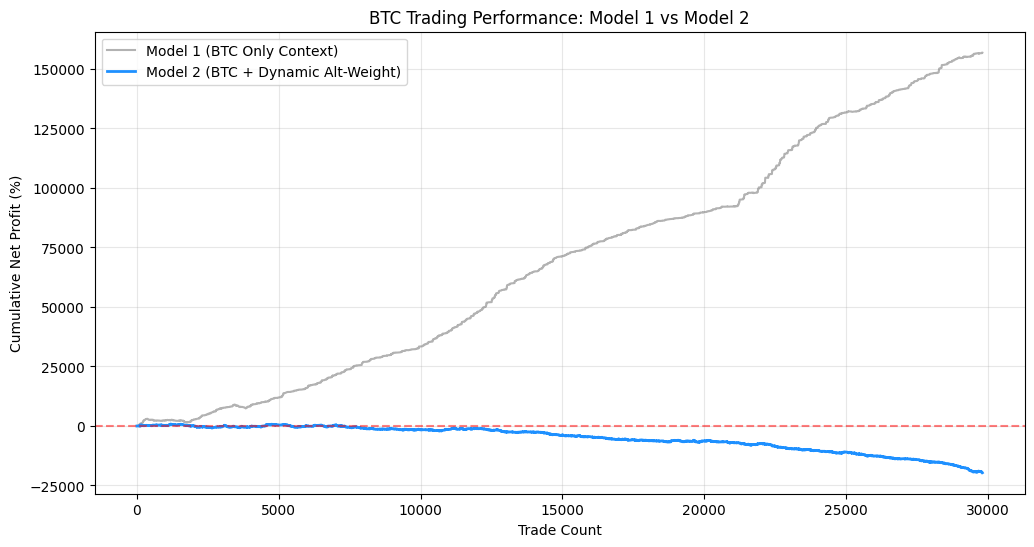

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 각 모델의 예측값 산출 (Numpy 변환으로 인덱스 에러 방지)
print("모델 예측 및 타점 추출 중")
p1 = np.array(model_1.predict(X_test_v2[features_v1]))
p2 = np.array(model_bin_v2.predict(X_test_v2))
actual_rets = merged.loc[~train_idx, 'target_return_30m'].values
fee = 0.05

# 2. 성과 분석 함수 (상위 0.5% 타점 기준)
def analyze_performance(probs, rets, fee=0.05):
    # 상위 0.5% 지점 찾기 (변별력이 낮아도 최소 0.5%는 뽑아냄)
    th = np.percentile(probs, 99.5)
    # 동일한 값이 많을 경우를 대비해 인덱스로 상위 N개 추출
    top_indices = np.argsort(probs)[-int(len(probs)*0.005):]
    
    trades = rets[top_indices]
    net_rets = trades - fee
    
    return {
        'count': len(trades),
        'win_rate': (trades > fee).mean() * 100,
        'total_profit': net_rets.sum(),
        'avg_profit': net_rets.mean(),
        'cum_ret': net_rets.cumsum(),
        'threshold': th
    }

# 3. 결과 계산
res_1 = analyze_performance(p1, actual_rets)
res_2 = analyze_performance(p2, actual_rets)

# 4. 비교 리포트 출력
print("\n" + "="*70)
print(f" [비트코인 매매] 모델 성능 최종 비교 리포트")
print("="*70)
print(f"{'지표 (Metric)':<20} | {'Model 1 (Baseline)':<20} | {'Model 2 (Dynamic)':<20}")
print("-" * 70)
print(f"{'진입 횟수':<20} | {res_1['count']:>20,} | {res_2['count']:>20,}")
print(f"{'승률 (Net)':<20} | {res_1['win_rate']:>19.2f}% | {res_2['win_rate']:>19.2f}%")
print(f"{'누적 수익률 (%)':<20} | {res_1['total_profit']:>19.2f}% | {res_2['total_profit']:>19.2f}%")
print(f"{'거래당 평균 수익':<20} | {res_1['avg_profit']:>19.4f}% | {res_2['avg_profit']:>19.4f}%")
print(f"{'임계값 (Thres)':<20} | {res_1['threshold']:>20.4f} | {res_2['threshold']:>20.4f}")
print("="*70)

# 5. 수익률 곡선 시각화
plt.figure(figsize=(12, 6))
plt.plot(res_1['cum_ret'], label='Model 1 (BTC Only Context)', color='gray', alpha=0.6)
plt.plot(res_2['cum_ret'], label='Model 2 (BTC + Dynamic Alt-Weight)', color='dodgerblue', linewidth=2)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('BTC Trading Performance: Model 1 vs Model 2')
plt.xlabel('Trade Count')
plt.ylabel('Cumulative Net Profit (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

현재 Model 2는 승률은 높지만 한 번 터질 때 크게 잃는 '전형적인 고점 추격형' 모델입니다. 이를 해결하기 위해 단순히 "오르냐 마느냐"가 아니라 **"손절선보다 익절선에 먼저 도달하느냐"**를 맞추는 손익비(Risk/Reward) 타겟으로 재학습 vlfdy

In [9]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import gc

# 1. 동적 가중치(Rolling Corr) 피처 재생성 (KeyError 방지)
print("🔄 동적 가중치 피처 생성 및 데이터 정제 중...")
window = 1440 
target_markets = ['KRW-ETH', 'KRW-SOL', 'KRW-XRP', 'KRW-DOGE', 'KRW-ENSO']

# 중복 제거 및 피벗
selected_df = merged[merged['market'].isin(target_markets + ['KRW-BTC'])]
clean_df = selected_df.groupby(['timestamp_kst', 'market'])['close_u'].mean().reset_index()
price_pivot = clean_df.pivot(index='timestamp_kst', columns='market', values='close_u').astype('float32')
returns_pivot = price_pivot.pct_change()

# 동적 가중합 계산
merged['dynamic_coupling'] = 0.0
for market in target_markets:
    rolling_corr = returns_pivot[market].rolling(window=window).corr(returns_pivot['KRW-BTC'])
    merged['dynamic_coupling'] += (merged['timestamp_kst'].map(rolling_corr) * merged['timestamp_kst'].map(returns_pivot[market])).fillna(0)

# 수치 안정화 (Replace & Clip)
merged['dynamic_coupling'] = merged['dynamic_coupling'].replace([np.inf, -np.inf], 0).fillna(0).clip(-0.1, 0.1)

# 2. 손익비 기반 타겟 생성 (익절 1.0% / 손절 0.5%)
print("🎯 손익비 기반 타겟(Target_RR) 생성 중...")
take_profit = 1.0
merged['target_rr'] = (merged['target_return_30m'] >= take_profit).astype(int)

# 3. 데이터 분할 및 학습 준비
features_v2 = [
    'close_u', 'close_b', 'kimp_real', 'kimp_velocity', 
    'market_fx', 'volatility_30m', 'taker_buy_base_volume', 'hour',
    'upbit_dom', 'binance_dom', 'dom_gap',
    'dynamic_coupling'
]

train_idx = merged['timestamp_kst'] < '2025-01-01'
X_train = merged.loc[train_idx, features_v2].astype('float32')
y_train = merged.loc[train_idx, 'target_rr'].astype('int32')
X_test = merged.loc[~train_idx, features_v2].astype('float32')
y_test = merged.loc[~train_idx, 'target_rr'].astype('int32')

# 클래스 불균형 해결 (1이 매우 적으므로 필수)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 4. 모델 파라미터 (AUC 최적화 및 안정성 중점)
params_rr = {
    'objective': 'binary',
    'metric': 'auc',
    'device': 'gpu',
    'learning_rate': 0.01,
    'num_leaves': 127,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'scale_pos_weight': pos_weight,
    'verbose': -1
}

train_set = lgb.Dataset(X_train, label=y_train)
test_set = lgb.Dataset(X_test, label=y_test, reference=train_set)

print("🚀 손익비 기반 Model 2 재학습 시작...")
model_bin_rr = lgb.train(params_rr, train_set, valid_sets=[test_set], 
                         num_boost_round=1500, 
                         callbacks=[lgb.early_stopping(stopping_rounds=100)])

# 5. 메모리 정리
del selected_df, clean_df, price_pivot, returns_pivot
gc.collect()

🔄 동적 가중치 피처 생성 및 데이터 정제 중...


C:\Users\user\AppData\Local\Temp\ipykernel_24816\3673292306.py:15: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_pivot = price_pivot.pct_change()


🎯 손익비 기반 타겟(Target_RR) 생성 중...


KeyError: "['upbit_dom', 'binance_dom', 'dom_gap'] not in index"

## 피처 중요도(Gain) 확인 및 하위 제거
Split(단순 사용 횟수)이 아니라 Gain(수익성 기여도)을 기준으로 상위 피처를 선별합니다.

In [ ]:
# 1. Gain 기반 피처 중요도 추출
deploy_model = model_bin_rr # 아까 학습한 손익비 모델
fi = pd.DataFrame({
    'feature': features_v2,
    'importance': deploy_model.feature_importance(importance_type='gain')
}).sort_values(by='importance', ascending=False)

print("📊 피처별 기여도(Gain) 순위:")
print(fi)

# 시각화
plt.figure(figsize=(10, 6))
plt.barh(fi['feature'], fi['importance'], color='royalblue')
plt.gca().invert_yaxis()
plt.title('Feature Importance (Gain)')
plt.show()

# 2. 하위 20~30% 피처 제거 (예: 중요도가 너무 낮은 3-4개 제거)
# 여기서는 상위 8개만 쓰기로 결정했다고 가정합니다.
top_features = fi.head(8)['feature'].tolist()
print(f"\n✅ 선별된 핵심 피처 ({len(top_features)}개):")
print(top_features)

In [ ]:
# 선별된 피처로 데이터셋 재구성
X_train_slim = merged.loc[train_idx, top_features].astype('float32')
y_train_slim = merged.loc[train_idx, 'target_rr'].astype('int32')
X_test_slim = merged.loc[~train_idx, top_features].astype('float32')
y_test_slim = merged.loc[~train_idx, 'target_rr'].astype('int32')

# 모델 파라미터는 동일하게 유지하되, 피처가 적으므로 num_leaves를 살짝 줄여 안정화
params_slim = params_rr.copy()
params_slim['num_leaves'] = 31 # 피처가 적을 땐 트리를 너무 깊게 안 짜는 게 정석

train_set_slim = lgb.Dataset(X_train_slim, label=y_train_slim)
test_set_slim = lgb.Dataset(X_test_slim, label=y_test_slim, reference=train_set_slim)

print(f"🔥 핵심 {len(top_features)}개 피처로 슬림 모델 학습 시작...")
model_slim = lgb.train(params_slim, train_set_slim, valid_sets=[test_set_slim], 
                       num_boost_round=1000, 
                       callbacks=[lgb.early_stopping(stopping_rounds=100)])